# AAV5 — Récupération du modèle de Potts pour la viabilité (cible recalculée, eps=0.5)

`AAV5_SEL_potts_regression.ipynb` fitte `viab` directement sur la colonne fournie
`log2_enrichissement_virus_sur_plasmide` du CSV IDV (held-out r = +0.204, `LAM=0`). Cette
colonne ne se reconstruit pas exactement en `log2((compte_virus+1)/(compte_plasmide+1))`
(écart max ~1.4, vérifié en session) — son pseudocount/normalisation réel est inconnu, ce qui
la rend incohérente avec le reste du projet.

**Convention adoptée (2026-09-11, cf. CLAUDE.md) : toujours `eps=0.5` pour un log enrichment
calculé par notre propre code.** Ce notebook recalcule donc la cible viabilité **nous-mêmes**,
directement à partir des comptages bruts (`compte_virus`, `compte_plasmide`) du CSV de
travail (`AAV5_organoides_sorted.csv`, §5 d'`AAV5_SEL_sorting.ipynb`) :

```
y = log2((compte_virus + 0.5) / (compte_plasmide + 0.5))
```

au lieu d'utiliser `log2_enrichissement_virus_sur_plasmide` telle quelle, puis refait le même
fit de Potts (`RegressionV1.fit_weights_potts_from_data`, même design 8541 features, même
pondération inverse-variance `w = 1/(1/(n_num+0.5) + 1/(n_den+0.5))` — déjà `eps=0.5`) pour
voir si le held-out r change. Terminologie du projet respectée : c'est un **log enrichment**,
jamais un "score" (le "score" est uniquement `F + J`, le résultat du fit).

### 0. Setup

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # avant l'init jax (RegressionV1 importe jax)
LIB = _root / "lib"

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson
assert "Modelization_V2" in R.__file__, R.__file__
print(R.message, "|", R.__file__)

L, A = 7, 20
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

file regression 1.5 | /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/RegressionV1.py


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Chargement + cible recalculée (eps=0.5) vs colonne fournie

(3822400, 4)
écart (recalculé eps=0.5) - (colonne CSV) : mean=-1.063  std=0.282  max|diff|=1.331
Pearson r(y_eps05, y_csv) = 0.9977


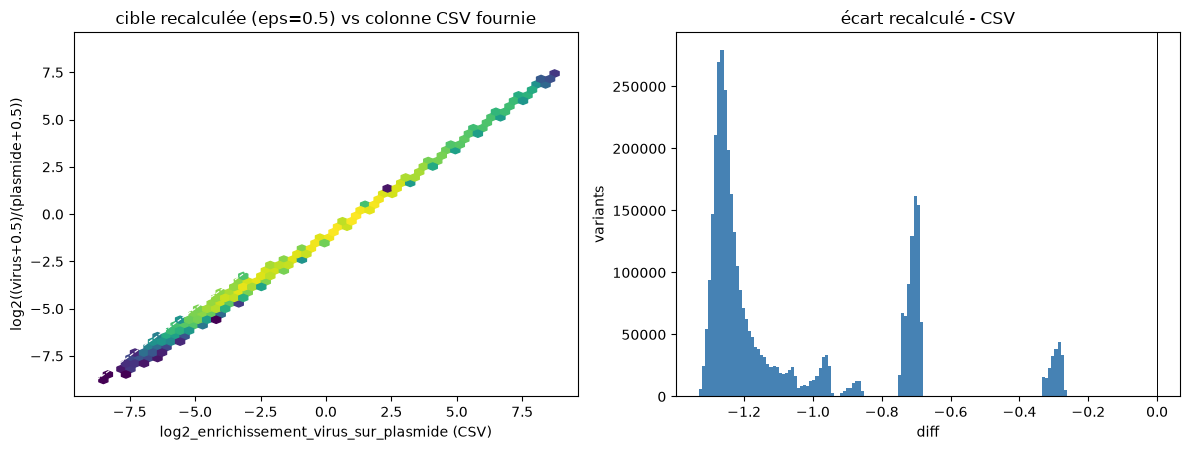

In [2]:
CSV = Path("AAV5_organoides_sorted.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides_sorted.csv"
assert CSV.exists(), CSV

use_cols = ["sequence", "compte_plasmide", "compte_virus", "log2_enrichissement_virus_sur_plasmide"]
dtypes = {"sequence": "string", **{c: "float32" for c in use_cols if c != "sequence"}}
df = pd.read_csv(CSV, usecols=use_cols, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(df.shape)

EPS = 0.5
c_plasmide = df["compte_plasmide"].to_numpy(np.float64)
c_virus    = df["compte_virus"].to_numpy(np.float64)
y_csv      = df["log2_enrichissement_virus_sur_plasmide"].to_numpy(np.float64)
y_eps05    = np.log2((c_virus + EPS) / (c_plasmide + EPS))

diff = y_eps05 - y_csv
print(f"écart (recalculé eps=0.5) - (colonne CSV) : "
      f"mean={diff.mean():+.3f}  std={diff.std():.3f}  max|diff|={np.abs(diff).max():.3f}")
print(f"Pearson r(y_eps05, y_csv) = {pearson(y_eps05, y_csv):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hexbin(y_csv, y_eps05, gridsize=50, bins="log", mincnt=1, cmap="viridis")
lo, hi = min(y_csv.min(), y_eps05.min()), max(y_csv.max(), y_eps05.max())
axes[0].plot([lo, hi], [lo, hi], "w--", lw=0.8)
axes[0].set(title="cible recalculée (eps=0.5) vs colonne CSV fournie",
            xlabel="log2_enrichissement_virus_sur_plasmide (CSV)",
            ylabel="log2((virus+0.5)/(plasmide+0.5))")

axes[1].hist(diff, bins=120, color="steelblue")
axes[1].axvline(0, color="k", lw=0.7)
axes[1].set(title="écart recalculé - CSV", xlabel="diff", ylabel="variants")
plt.tight_layout(); plt.show()

### 2. Encodage des séquences + fit Potts (même recette que `AAV5_SEL_potts_regression.ipynb`)

Split 50/50, poids d'observation `w = 1/(1/(n_num+0.5) + 1/(n_den+0.5))` (approx. variance d'un
log-ratio de comptages Poisson, déjà en `eps=0.5`), fit sur `N_FIT` lignes, évaluation held-out
sur `N_EVAL` lignes disjointes. `LAM=0.0` (OLS minimum-norm, même choix que la cible CSV — la CV
y tombait sur des λ énormes qui écrasent F/J, cf. `AAV5_SEL_potts_regression.ipynb`).

In [3]:
seq_bytes = np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), L)
print("seq_matrix:", seq_matrix.shape)


def score_FJ(seq, F, J):
    F, J = np.asarray(F), np.asarray(J)
    Fp = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    Jp = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            Jp += J[i, j, seq[:, i], seq[:, j]]
    return Fp + Jp


LAM   = 0.0
N_FIT, N_EVAL = 80_000, 150_000
RNG   = np.random.default_rng(0)

w_all = 1.0 / (1.0 / (c_virus + 0.5) + 1.0 / (c_plasmide + 0.5))
idx = np.flatnonzero(np.isfinite(y_eps05))
y, S, w = y_eps05[idx], seq_matrix[idx], w_all[idx]
eff_n = w.sum() ** 2 / (w ** 2).sum()

tr, te  = train_test_split(np.arange(len(idx)), test_size=0.5, random_state=0)
fit_i   = tr if len(tr) <= N_FIT  else RNG.choice(tr, N_FIT,  replace=False)
eval_i  = te if len(te) <= N_EVAL else RNG.choice(te, N_EVAL, replace=False)

F, J, rank, info = R.fit_weights_potts_from_data(
    S[fit_i], y[fit_i], sample_weight=w[fit_i], seed=0, verbose=False, lam=LAM)
F, J = np.asarray(F), np.asarray(J)

pred_eval = score_FJ(S[eval_i], F, J)
y_eval    = y[eval_i]
w_eval    = w[eval_i]
hi_mask   = w_eval > np.quantile(w_eval, 0.90)

r_all  = pearson(y_eval, pred_eval)
r_deep = pearson(y_eval[hi_mask], pred_eval[hi_mask])

n_features = A * L + L * (L - 1) // 2 * A * A + 1   # single-site + pairwise off-diag (unordered) + bias
print(f"n_finite={len(idx):,}  eff_n(pondéré)={eff_n:,.0f}  rank={rank}/{n_features}  lambda={info['lam']}")
print(f"held-out r: all={r_all:+.3f}  deep10%={r_deep:+.3f}")
print(f"\npour comparaison -- cible CSV fournie (AAV5_SEL_potts_regression.ipynb): r_all=+0.204 (lam=0), +0.217 (CV)")

seq_matrix: (3822400, 7)


n_finite=3,822,400  eff_n(pondéré)=1,869,391  rank=4891/8541  lambda=0.0
held-out r: all=+0.202  deep10%=+0.131

pour comparaison -- cible CSV fournie (AAV5_SEL_potts_regression.ipynb): r_all=+0.204 (lam=0), +0.217 (CV)


### 3. Diagnostic du fit — score prédit vs cible recalculée (held-out)

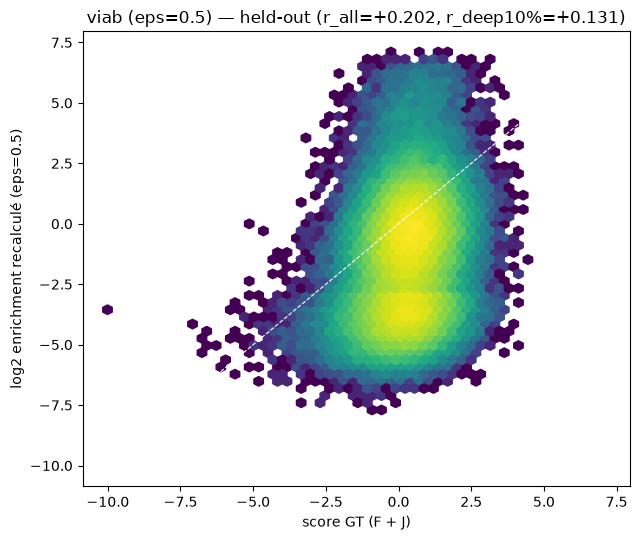

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.hexbin(pred_eval, y_eval, gridsize=45, bins="log", mincnt=1, cmap="viridis")
lo, hi = min(pred_eval.min(), y_eval.min()), max(pred_eval.max(), y_eval.max())
ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
ax.set(title=f"viab (eps=0.5) — held-out (r_all={r_all:+.3f}, r_deep10%={r_deep:+.3f})",
       xlabel="score GT (F + J)", ylabel="log2 enrichment recalculé (eps=0.5)")
plt.tight_layout(); plt.show()

### 4. Poids F (profil) et J (couplages)

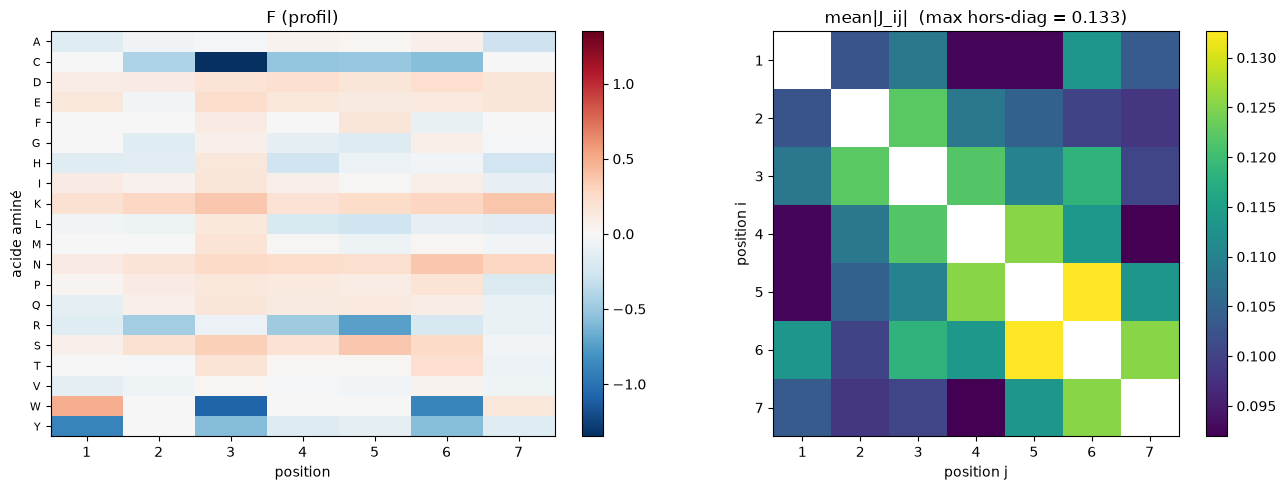

mean|J|/mean|F| = 0.519


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vmax = np.abs(F).max() or 1.0
im = axes[0].imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_xticks(range(L)); axes[0].set_xticklabels(range(1, L + 1))
axes[0].set_yticks(range(A)); axes[0].set_yticklabels(AA_LABELS, fontsize=8)
axes[0].set(title="F (profil)", xlabel="position", ylabel="acide aminé")
fig.colorbar(im, ax=axes[0], fraction=0.046)

Jabs = np.abs(J).mean(axis=(2, 3))
off = Jabs.copy(); np.fill_diagonal(off, np.nan)
im2 = axes[1].imshow(off, cmap="viridis")
axes[1].set_xticks(range(L)); axes[1].set_xticklabels(range(1, L + 1))
axes[1].set_yticks(range(L)); axes[1].set_yticklabels(range(1, L + 1))
axes[1].set(title=f"mean|J_ij|  (max hors-diag = {np.nanmax(off):.3f})",
            xlabel="position j", ylabel="position i")
fig.colorbar(im2, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

ratio = np.abs(J).mean() / (np.abs(F).mean() + 1e-12)
print(f"mean|J|/mean|F| = {ratio:.3f}")

### 5. Distribution du score GT sur la librairie de travail

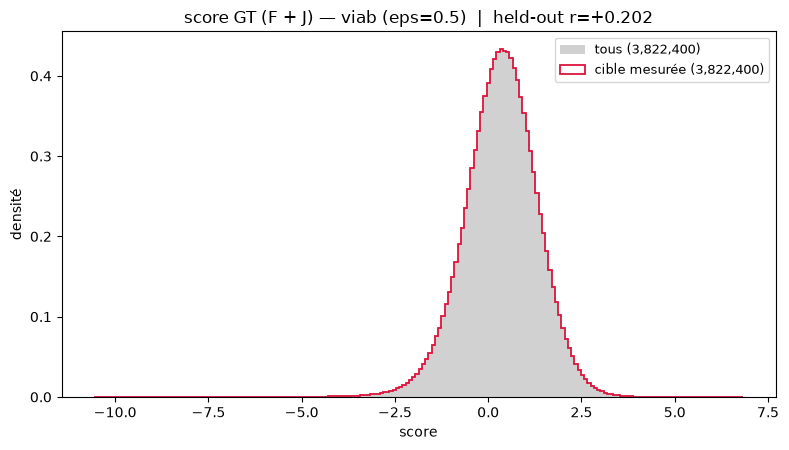

In [6]:
score_full = score_FJ(seq_matrix, F, J)
finite = np.isfinite(y_eps05)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(score_full, bins=200, density=True, color="0.82", label=f"tous ({score_full.size:,})")
ax.hist(score_full[finite], bins=200, density=True, histtype="step", color="crimson", lw=1.3,
        label=f"cible mesurée ({int(finite.sum()):,})")
ax.set(title=f"score GT (F + J) — viab (eps=0.5)  |  held-out r={r_all:+.3f}",
       xlabel="score", ylabel="densité")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 6. Résidus held-out

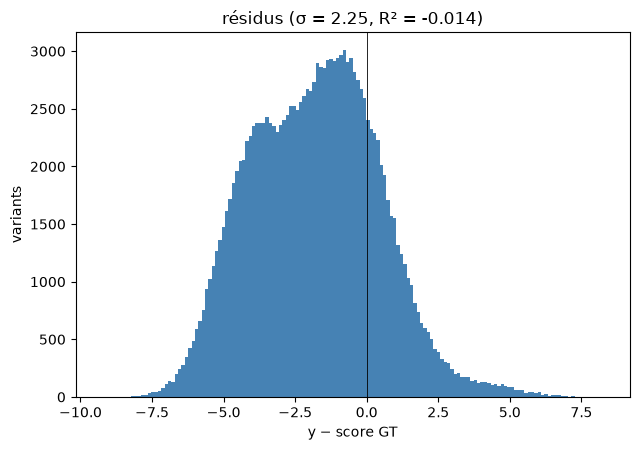

In [7]:
resid = y_eval - pred_eval
fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.hist(resid, bins=150, color="steelblue")
ax.axvline(0, color="k", lw=0.6)
ax.set(title=f"résidus (σ = {resid.std():.2f}, R² = {1 - resid.var() / np.var(y_eval):.3f})",
       xlabel="y − score GT", ylabel="variants")
plt.tight_layout(); plt.show()

### 7. Export des poids

Tag `_eps05_` pour ne pas écraser `aav5_{F,J}_viab_potts_sorted_unreg.npy` (fit sur la colonne
CSV fournie, `AAV5_SEL_potts_regression.ipynb`).

In [8]:
fp_F = LIB / "aav5_F_viab_eps05_potts_sorted_unreg.npy"
fp_J = LIB / "aav5_J_viab_eps05_potts_sorted_unreg.npy"
np.save(fp_F, np.asarray(F, np.float32))
np.save(fp_J, np.asarray(J, np.float32))
print(f"  {fp_F.name}   {fp_J.name}   (lambda={info['lam']}, held-out r={r_all:+.3f})")

  aav5_F_viab_eps05_potts_sorted_unreg.npy   aav5_J_viab_eps05_potts_sorted_unreg.npy   (lambda=0.0, held-out r=+0.202)


### 8. Conclusion

La cible recalculée en `eps=0.5` diffère de la colonne CSV fournie (§1), mais le fit de Potts
sur cette cible propre donne-t-il un held-out r meaningfully différent de +0.204/+0.217 ? Le
chiffre affiché en §2 tranche. Si le r reste comparable, le plafond ~0.2 sur `viab` n'est pas un
artefact du pseudocount de la colonne fournie -- c'est bien un plafond de signal, cohérent avec
le diagnostic déjà fait dans cette session (le filtrage par profondeur `compte_virus` ne
l'améliore pas non plus, contrairement à `sel_org2`/`sel_org3`).